In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

In [32]:
dag_path        = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit"
hese_path       = f"{dag_path}/hese/"
hese_flux_path       = f"{dag_path}/hese/flux_uncertainty_doug"
globalfit_minimizer_path  = f"{dag_path}/globalfit/debug_minimizer"
globalfit_path  = f"{dag_path}/globalfit/datasets_v1/Poisson"
globalfit_hese_1st_path = f"{dag_path}/globalfit_hese/first_try"
globalfit_hese_path = f"{dag_path}/globalfit_hese/datasets_v1/Poisson"
globalfit_hese_flux_path = f"{dag_path}/globalfit_hese/flux_uncertainty_doug"

scan_dir_dict = {
    # # --- HESE spice ----
    # "hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice": f"{hese_path}/spice/hese_HESEBestfit_SPL_noinel_nosyst_Poisson",
    # "hese_SPL_noinel_nosyst_Poisson_spice": f"{hese_path}/spice/hese_SPL_noinel_nosyst_Poisson",
    # # "hese_BPL_noinel_nosyst_Poisson": f"{hese_path}/spice/hese_BPL_noinel_nosyst_Poisson", # not possible, no fluxless_weight

    # # --- HESE ----
    # "hese_HESEBestfit_SPL_noinel_nosyst_SAY": f"{hese_path}/SAY/hese_HESEBestfit_SPL_noinel_nosyst",
    # "hese_SPL_noinel_nosyst_SAY":             f"{hese_path}/SAY/hese_SPL_noinel_nosyst",
    # "hese_BPL_noinel_nosyst_SAY":             f"{hese_path}/SAY/hese_BPL_noinel_nosyst",

    # "hese_HESEBestfit_SPL_noinel_nosyst_Poisson": f"{hese_path}/Poisson/hese_HESEBestfit_SPL_noinel_nosyst",
    # "hese_SPL_noinel_nosyst_Poisson":             f"{hese_path}/Poisson/hese_SPL_noinel_nosyst",
    # "hese_BPL_noinel_nosyst_Poisson":             f"{hese_path}/Poisson/hese_BPL_noinel_nosyst",

    # "hese_HESEBestfit_SPL_noinel_Poisson": f"{hese_path}/systematics/first_try/hese_HESEBestfit_SPL_noinel",
    # "hese_SPL_noinel_Poisson":             f"{hese_path}/systematics/first_try/hese_SPL_noinel",
    # "hese_BPL_noinel_Poisson":             f"{hese_path}/systematics/first_try/hese_BPL_noinel",

    # "hese_HESEBestfit_SPL_gamma_low":             f"{hese_flux_path}/hese_HESEBestfit_SPL_gamma_low",
    # "hese_HESEBestfit_SPL_gamma_high":             f"{hese_flux_path}/hese_HESEBestfit_SPL_gamma_high",
    # "hese_HESEBestfit_SPL_phi_low":             f"{hese_flux_path}/hese_HESEBestfit_SPL_phi_low",
    # "hese_HESEBestfit_SPL_phi_high":             f"{hese_flux_path}/hese_HESEBestfit_SPL_phi_high",

    # # --- Globalfit ---
    # "globalfit_double_SPL_LBFGSB_Poisson":           f"{globalfit_minimizer_path}/globalfit_double_SPL_LBFGSB_Poisson",
    # "globalfit_double_nohese_SPL_LBFGSB_Poisson":           f"{globalfit_minimizer_path}/globalfit_double_nohese_SPL_LBFGSB_Poisson",

    # "globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center":           f"{globalfit_minimizer_path}/globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center",
    # "globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center":           f"{globalfit_minimizer_path}/globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center",

    # "globalfit_double_no_hybrid_SPL_nosyst":           f"{globalfit_path}/globalfit_double_no_hybrid_SPL_nosyst",
    # "globalfit_double_no_hybrid_nohese_SPL_nosyst":           f"{globalfit_path}/globalfit_double_no_hybrid_nohese_SPL_nosyst",

    # "globalfit_double_no_hybrid_BPL_nosyst":           f"{globalfit_path}/globalfit_double_no_hybrid_BPL_nosyst",
    # "globalfit_double_no_hybrid_nohese_BPL_nosyst":           f"{globalfit_path}/globalfit_double_no_hybrid_nohese_BPL_nosyst",

    # "globalfit_double_no_hybrid_SPL":           f"{globalfit_path}/globalfit_double_no_hybrid_SPL",
    # "globalfit_double_no_hybrid_nohese_SPL":           f"{globalfit_path}/globalfit_double_no_hybrid_nohese_SPL",

    # "globalfit_double_no_hybrid_BPL":           f"{globalfit_path}/globalfit_double_no_hybrid_BPL",
    # "globalfit_double_no_hybrid_nohese_BPL":           f"{globalfit_path}/globalfit_double_no_hybrid_nohese_BPL",


    # # --- Globalfit+HESE ---
    # "globalfit_double_hese_SPL":             f"{globalfit_hese_1st_path}/globalfit_double_hese_SPL",
    # "globalfit_double_hese_BPL_range_philipp_strict":             f"{globalfit_hese_1st_path}/globalfit_double_hese_BPL_range_philipp_strict",
    # "globalfit_double_hese_BPL_range_philipp_strict_fine_center":             f"{globalfit_hese_1st_path}/globalfit_double_hese_BPL_range_philipp_strict_fine_center",

    # "globalfit_double_no_hybrid_hese_SPL_nosyst":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_SPL_nosyst",
    "globalfit_double_no_hybrid_hese_BPL_nosyst":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_BPL_nosyst",

    # "globalfit_double_no_hybrid_hese_SPL":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_SPL",
    # "globalfit_double_no_hybrid_hese_BPL":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_BPL",

    # "globalfit_double_no_hybrid_hese_SPL_clean_hese_nosyst":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_SPL_clean_hese_nosyst",

    # "globalfit_double_no_hybrid_hese_HESEBestfit_SPL":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL",
    # "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high",
    # "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low",
    # "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_high":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_high",
    # "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_low":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_low",

    "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center",
    "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high_fine_center":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high_fine_center",
    "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low_fine_center":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low_fine_center",
    "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_high_fine_center":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_high_fine_center",
    "globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_low_fine_center":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_low_fine_center",


    # "globalfit_double_no_hybrid_hese_BPL_range_philipp":             f"{globalfit_hese_flux_path}/globalfit_double_no_hybrid_hese_BPL",

}

In [4]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/presentations/2026-03-25_diffuse_update"
os.system(f"mkdir -p {plotting_path}")

0

In [38]:
# load the data
N_grid = 60 # 20 was standard
drop_unsuccessful = False
scan_dict = {}
data = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "newflavorparam" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=N_grid)


globalfit_double_no_hybrid_hese_BPL_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v1/Poisson/globalfit_double_no_hybrid_hese_BPL_nosyst
removed stuff
globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/flux_uncertainty_doug/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center
removed stuff
globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high_fine_center
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/flux_uncertainty_doug/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high_fine_center
removed stuff
globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low_fine_center
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/flux_uncertainty_doug/globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low_fine_center
remo

Compare HESEBestFit performance with BPL

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_hese_BPL_nosyst / globalfit_double_no_hybrid_hese_BPL_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center / globalfit_double_no_hybrid_hese_BPL_nosyst) at 68%: 0.6869


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

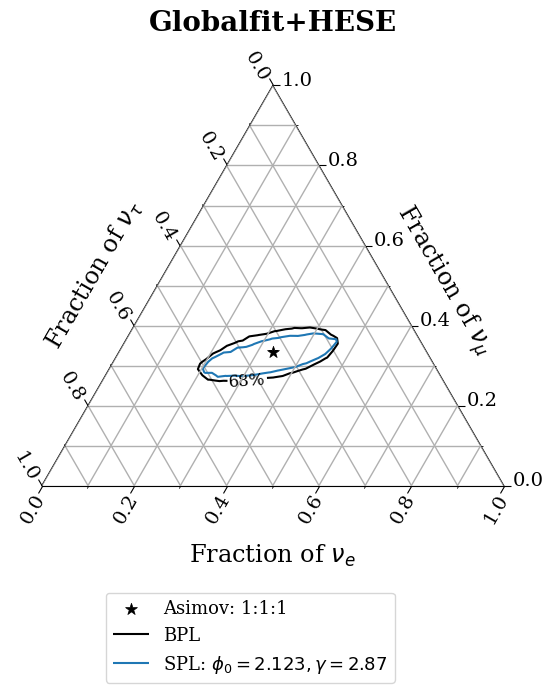

In [29]:
# compare_HESEBestfit_BPL_globalfit_double_hese
names = [
"globalfit_double_no_hybrid_hese_BPL_nosyst",
"globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center"
]
labels = [
    "BPL",
    r"SPL: $\phi_0 = 2.123,\gamma=2.87$"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = "Globalfit+HESE",
                  savepath = f"{plotting_path}/compare_HESEBestfit_BPL_globalfit_double_hese.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_BPL_nosyst", levels=["68%"] )

I created new datasets, where I remade Philipps files, and I did fits without the hybrid class. 
This is normal for the globalfit, because this part is taken over by the Northern Tracks.

We have changes to:
- globalfit_double_SPL_LBFGSB_Poisson: tells me 7% worse, but I dont see anything
- globalfit_double_nohese_SPL_LBFGSB_Poisson: 2% worse, not visible
- BPL: 3%, not visible
- BPL no hese: same same, one failed fit

- combined SPL: 13%, but not visible
- combined BPL: 7%, but not visible

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_SPL_LBFGSB_Poisson / globalfit_double_SPL_LBFGSB_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_SPL_nosyst / globalfit_double_SPL_LBFGSB_Poisson) at 68%: 1.0787


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

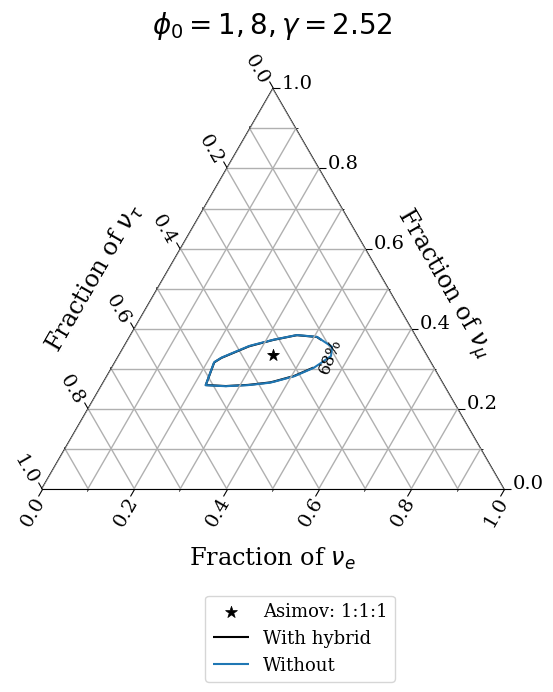

In [8]:
# globalfit_double_SPL_with_without_hybrid
names = [
"globalfit_double_SPL_LBFGSB_Poisson",
"globalfit_double_no_hybrid_SPL_nosyst"
]
labels = [
    "With hybrid",
    "Without"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1,8,\gamma=2.52$",
                  savepath = f"{plotting_path}/globalfit_double_SPL_with_without_hybrid.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_SPL_LBFGSB_Poisson", levels=["68%"] )

Area ratio (globalfit_double_nohese_SPL_LBFGSB_Poisson / globalfit_double_nohese_SPL_LBFGSB_Poisson) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_nohese_SPL_nosyst / globalfit_double_nohese_SPL_LBFGSB_Poisson) at 68%: 1.0208


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

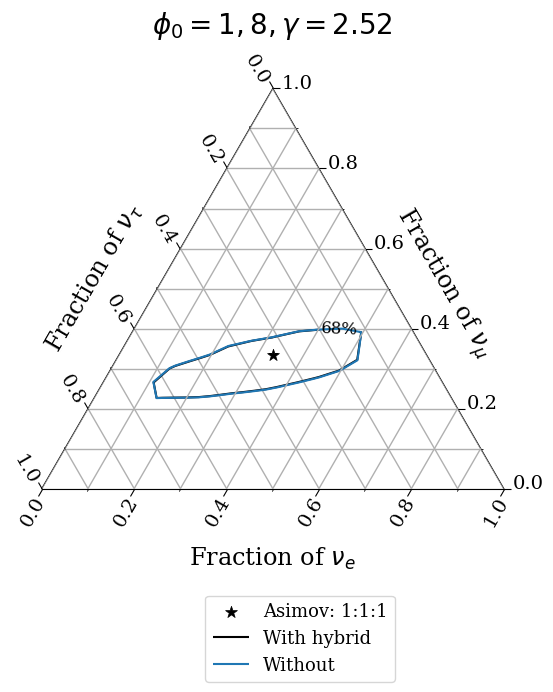

In [9]:
# globalfit_double_nohese_SPL_with_without_hybrid
names = [
"globalfit_double_nohese_SPL_LBFGSB_Poisson",
"globalfit_double_no_hybrid_nohese_SPL_nosyst"
]
labels = [
    "With hybrid",
    "Without"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1,8,\gamma=2.52$",
                  savepath = f"{plotting_path}/globalfit_double_nohese_SPL_with_without_hybrid.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_nohese_SPL_LBFGSB_Poisson", levels=["68%"] )

Area ratio (globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center / globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_BPL_nosyst / globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center) at 68%: 1.0336


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

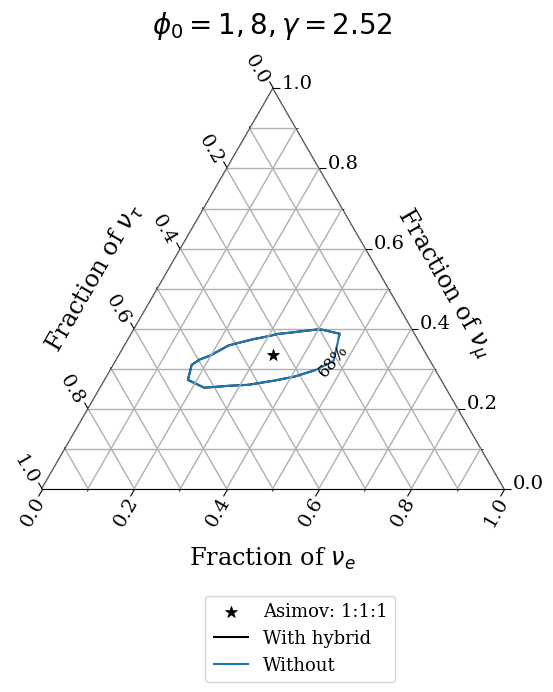

In [10]:
# globalfit_double_BPL_with_without_hybrid
names = [
"globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center",
"globalfit_double_no_hybrid_BPL_nosyst"
]
labels = [
    "With hybrid",
    "Without"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1,8,\gamma=2.52$",
                  savepath = f"{plotting_path}/globalfit_double_BPL_with_without_hybrid.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_BPL_range_philipp_strict_LBFGSB_fine_center", levels=["68%"] )

Area ratio (globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center / globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_nohese_BPL_nosyst / globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center) at 68%: 0.9822


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

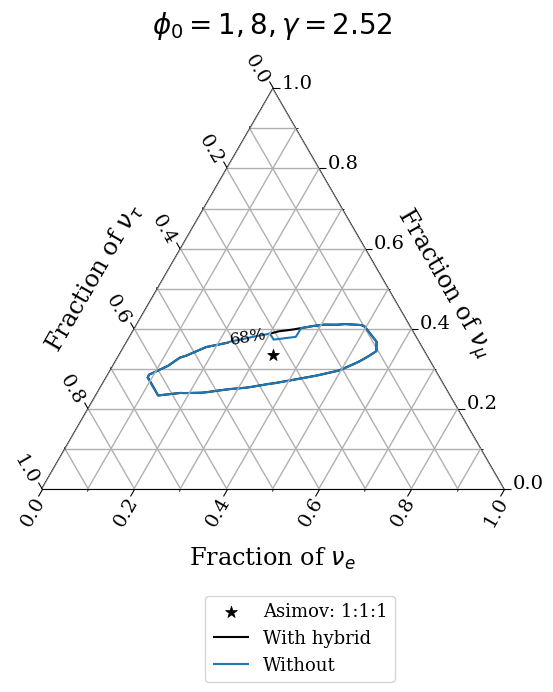

In [11]:
# globalfit_double_nohese_BPL_with_without_hybrid
names = [
"globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center",
"globalfit_double_no_hybrid_nohese_BPL_nosyst"
]
labels = [
    "With hybrid",
    "Without"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1,8,\gamma=2.52$",
                  savepath = f"{plotting_path}/globalfit_double_nohese_BPL_with_without_hybrid.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_nohese_BPL_range_philipp_strict_LBFGSB_fine_center", levels=["68%"] )

Area ratio (globalfit_double_hese_SPL / globalfit_double_hese_SPL) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_SPL_nosyst / globalfit_double_hese_SPL) at 68%: 1.1378


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

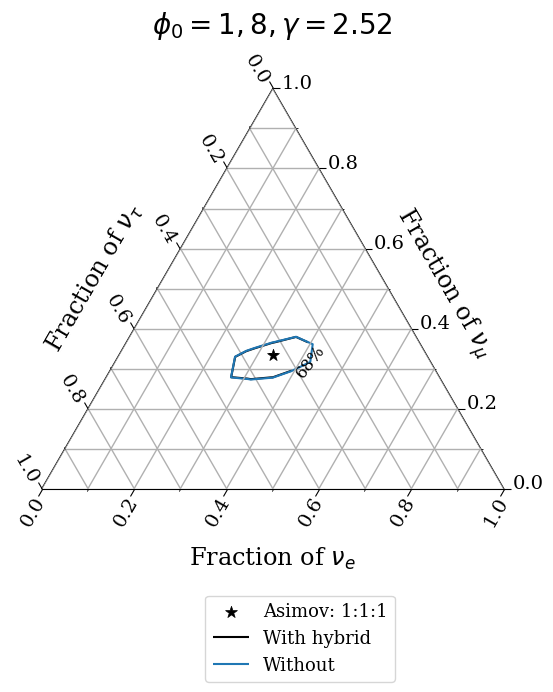

In [12]:
# globalfit_double_hese_SPL_with_without_hybrid
names = [
"globalfit_double_hese_SPL",
"globalfit_double_no_hybrid_hese_SPL_nosyst"
]
labels = [
    "With hybrid",
    "Without"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1,8,\gamma=2.52$",
                  savepath = f"{plotting_path}/globalfit_double_hese_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_hese_SPL", levels=["68%"] )

Area ratio (globalfit_double_hese_BPL_range_philipp_strict_fine_center / globalfit_double_hese_BPL_range_philipp_strict_fine_center) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_BPL_nosyst / globalfit_double_hese_BPL_range_philipp_strict_fine_center) at 68%: 1.0693


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

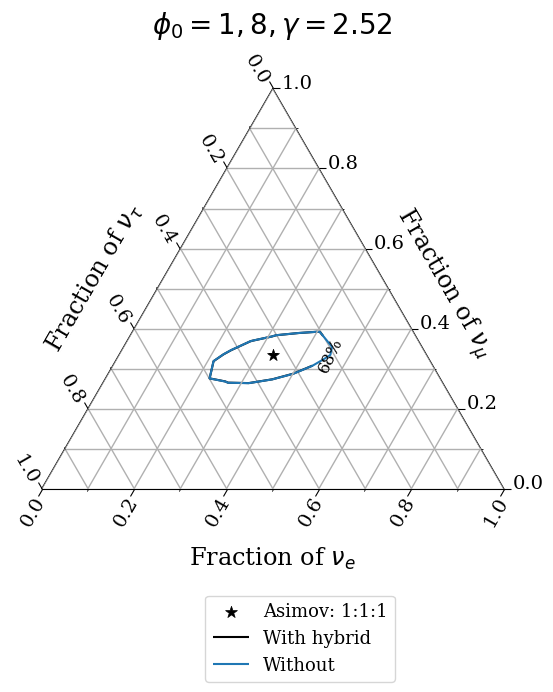

In [13]:
# globalfit_double_hese_BPL_with_without_hybrid
names = [
"globalfit_double_hese_BPL_range_philipp_strict_fine_center",
"globalfit_double_no_hybrid_hese_BPL_nosyst"
]
labels = [
    "With hybrid",
    "Without"
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1,8,\gamma=2.52$",
                  savepath = f"{plotting_path}/globalfit_double_hese_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_hese_BPL_range_philipp_strict_fine_center", levels=["68%"] )

Juliana asked me to check to remove the overlap from HESE.

Seems to be equal.

Area ratio (globalfit_double_no_hybrid_hese_SPL_nosyst / globalfit_double_no_hybrid_hese_SPL_clean_hese_nosyst) at 95%: 0.9915
Area ratio (globalfit_double_no_hybrid_hese_SPL_clean_hese_nosyst / globalfit_double_no_hybrid_hese_SPL_clean_hese_nosyst) at 95%: 1.0000


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

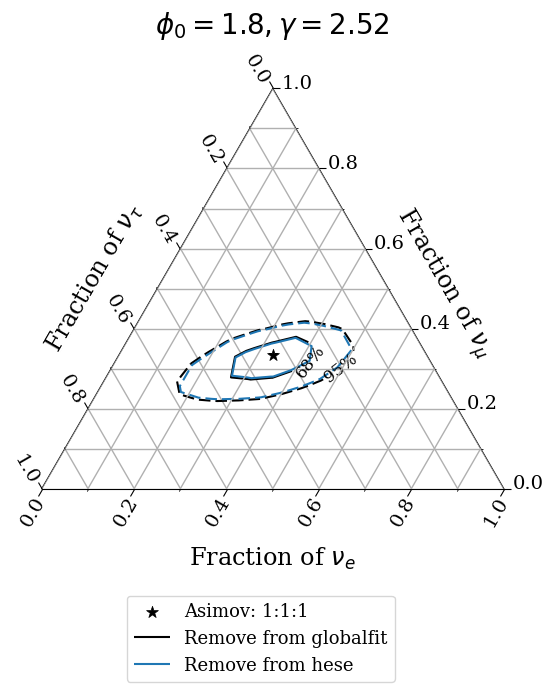

In [16]:
# compare_clean_hese_globalfit_juliana
names = [
"globalfit_double_no_hybrid_hese_SPL_nosyst",
"globalfit_double_no_hybrid_hese_SPL_clean_hese_nosyst",
]
labels = [
    "Remove from globalfit",
    "Remove from hese",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%","95%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  savepath = f"{plotting_path}/compare_clean_hese_globalfit_juliana.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_SPL_clean_hese_nosyst", levels=["95%"] )

Now i included systematics, lets see how much worse everything gets.

It gets more worse than I remembered from before, and the fits are very unstable. 
- HESE: unstable and significantly worse
- Globalfit: looks fine, slightly worse
- Globalfit without HESE: unstable
- Combined: SPL fine, BPL problems

I study the instabiltiies in debug_minimizer/systematics

HESE: seems to get stuck in local minimum. Perhaps retry multipe times and combine for best LLH?

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processi

Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_Poisson / hese_HESEBestfit_SPL_noinel_nosyst_Poisson) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_noinel_Poisson / hese_HESEBestfit_SPL_noinel_nosyst_Poisson) at 68%: 1.1803


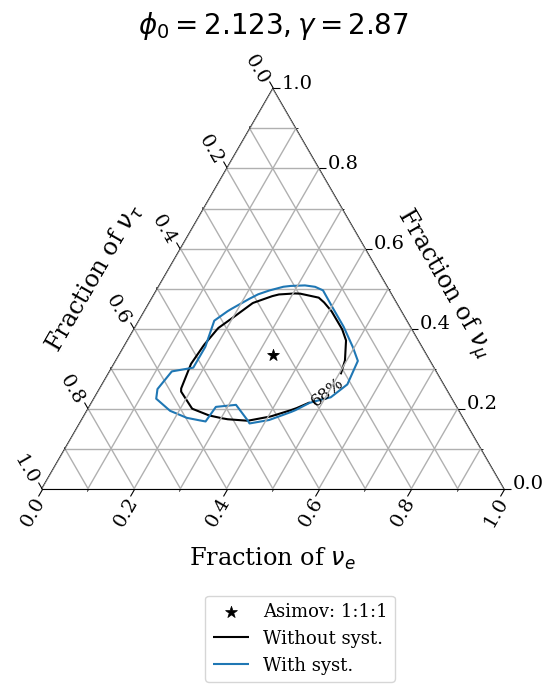

In [7]:
# compare_syst_hese_HESEBestfit_SPL
names = [
"hese_HESEBestfit_SPL_noinel_nosyst_Poisson",
"hese_HESEBestfit_SPL_noinel_Poisson"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.123,\gamma=2.87$",
                  savepath = f"{plotting_path}/compare_syst_hese_HESEBestfit_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_HESEBestfit_SPL_noinel_nosyst_Poisson", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (hese_SPL_noinel_nosyst_Poisson / hese_SPL_noinel_nosyst_Poisson) at 68%: 1.0000
Area ratio (hese_SPL_noinel_Poisson / hese_SPL_noinel_nosyst_Poisson) at 68%: 1.1183


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

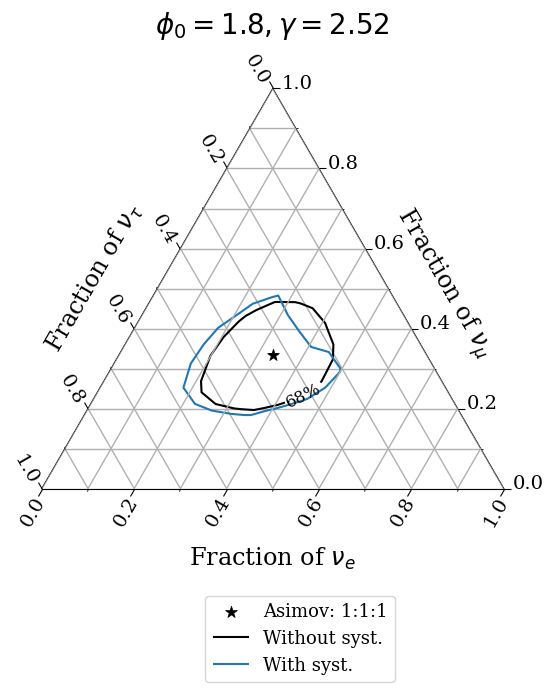

In [14]:
# compare_syst_hese_SPL
names = [
"hese_SPL_noinel_nosyst_Poisson",
"hese_SPL_noinel_Poisson"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  savepath = f"{plotting_path}/compare_syst_hese_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_SPL_noinel_nosyst_Poisson", levels=["68%"] )

Area ratio (hese_BPL_noinel_nosyst_Poisson / hese_BPL_noinel_nosyst_Poisson) at 68%: 1.0000
Area ratio (hese_BPL_noinel_Poisson / hese_BPL_noinel_nosyst_Poisson) at 68%: 1.1509


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

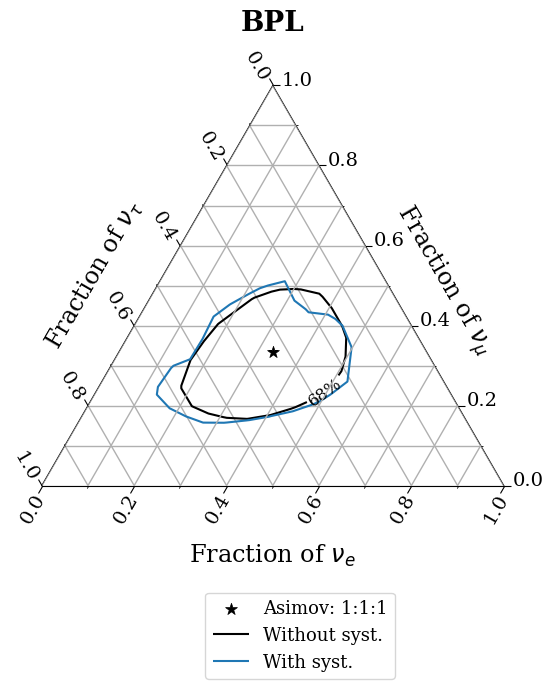

In [32]:
# compare_syst_hese_BPL
names = [
"hese_BPL_noinel_nosyst_Poisson",
"hese_BPL_noinel_Poisson"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"BPL",
                  savepath = f"{plotting_path}/compare_syst_hese_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_BPL_noinel_nosyst_Poisson", levels=["68%"] )

Globalfit seems better.
- SPL: almost the same. Did I actually fit systematics?
    - globalfit_double_no_hybrid_SPL_nosyst: no systematics
        - /scratch/tvaneede/NNMFit/condor/19_03_2026_08_52_57/logs/astro_nue_ratio_p0_1819_astro_nutau_ratio_p1_3644.err seems to be stuck at prompt norm = 0.0
        Fit result is: (8.133856733103048, {'astro_norm': 2.352631063394394, 'gamma_astro': 2.551239940228278, 'CR_grad': -0.5097949933551477, 'barr_h': -0.01601284841545904, 'barr_w': -0.05880956543191939, 'barr_y': 0.0863678658951137, 'barr_z': -0.08253534279754021, 'conv_norm': 0.9948865230182291, 'delta_gamma': 0.008773277951745194, 'muon_norm': 0.9978930882913802, 'prompt_norm': 0.0, 'effective_veto': 1.0116001622858235, 'muongun_norm': 0.9997381115330084}, {'success': False, 'message': 'ABNORMAL_TERMINATION_IN_LNSRCH', 'nfev': 490, 'nit': 385, 'warnflag': 2})
    -  globalfit_double_no_hybrid_SPL: got systematics
        - /scratch/tvaneede/NNMFit/condor/19_03_2026_18_48_04/logs/astro_nue_ratio_p0_1819_astro_nutau_ratio_p1_3644.err
        Fit result is: (7.813613690967489, {'astro_norm': 2.3488820196851266, 'gamma_astro': 2.548237263356716, 'CR_grad': -0.5402890224178959, 'barr_h': -0.012431683436332195, 'barr_w': -0.004981564694805925, 'barr_y': 0.050234873260473656, 'barr_z': -0.07514571718023982, 'conv_norm': 0.9934106600440523, 'delta_gamma': 0.01290686942289153, 'muon_norm': 0.998362966623709, 'prompt_norm': 0.0, 'effective_veto': 1.0086394317228573, 'muongun_norm': 0.9991097875561158, 'dom_eff': 0.9999078333565157, 'ice_abs': 0.9982337481437112, 'ice_scat': 1.0001719854953421, 'ice_holep0': 0.24489295107443151, 'ice_holep1': -0.057262550654772856, 'ice_crystal': 1.0008872627053471}, {'success': True, 'message': 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH', 'nfev': 2106, 'nit': 1470, 'warnflag': 0})

- BPL: both with and without systematics has problems

No hese
- SPL: fine. Did I fit systematics?
    - Yes!
- BPL: instabilities

Area ratio (globalfit_double_no_hybrid_SPL_nosyst / globalfit_double_no_hybrid_SPL_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_SPL / globalfit_double_no_hybrid_SPL_nosyst) at 68%: 1.1203


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

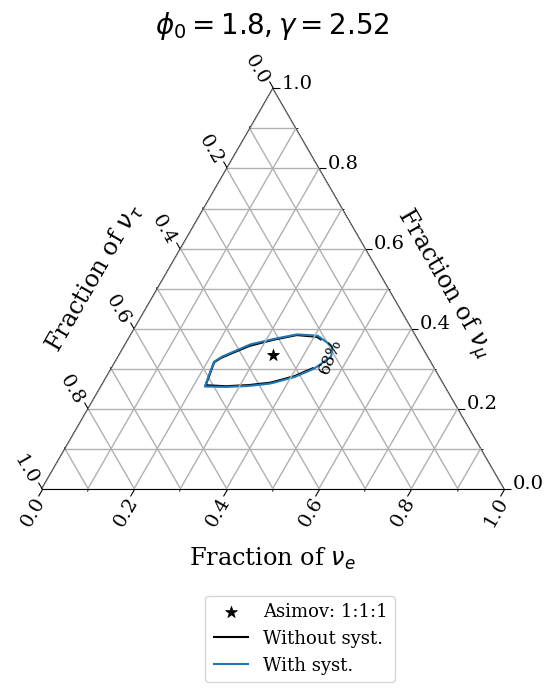

In [ ]:
# compare_syst_globalfit_double_no_hybrid_BPL
names = [
"globalfit_double_no_hybrid_SPL_nosyst",
"globalfit_double_no_hybrid_SPL"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_SPL_nosyst", levels=["68%"] )



/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processi

Area ratio (globalfit_double_no_hybrid_BPL_nosyst / globalfit_double_no_hybrid_BPL_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_BPL / globalfit_double_no_hybrid_BPL_nosyst) at 68%: 1.2557


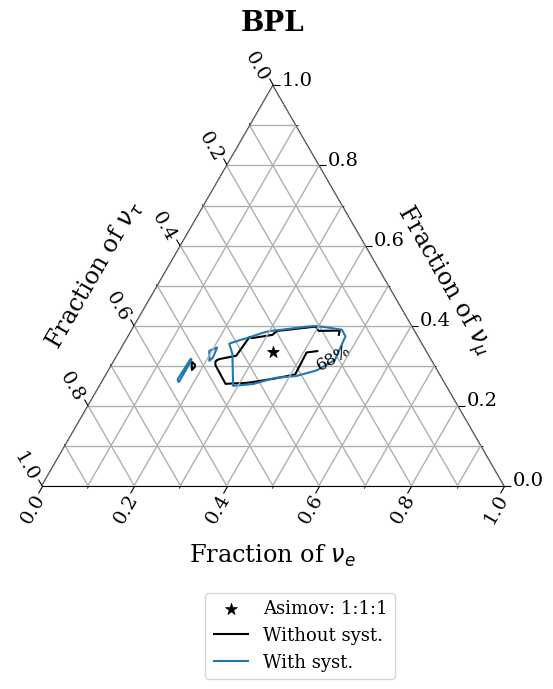

In [17]:
# compare_syst_globalfit_double_no_hybrid_SPL
names = [
"globalfit_double_no_hybrid_BPL_nosyst",
"globalfit_double_no_hybrid_BPL"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"BPL",
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_BPL_nosyst", levels=["68%"] )



Area ratio (globalfit_double_no_hybrid_nohese_SPL_nosyst / globalfit_double_no_hybrid_nohese_SPL_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_nohese_SPL / globalfit_double_no_hybrid_nohese_SPL_nosyst) at 68%: 1.0470


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

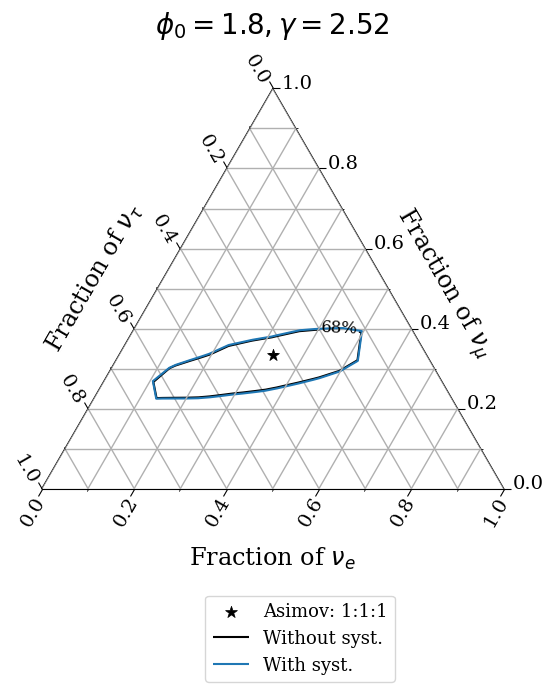

In [ ]:
# compare_syst_globalfit_double_no_hybrid_nohese_SPL
names = [
"globalfit_double_no_hybrid_nohese_SPL_nosyst",
"globalfit_double_no_hybrid_nohese_SPL"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_nohese_SPL_nosyst", levels=["68%"] )

Area ratio (globalfit_double_no_hybrid_nohese_BPL_nosyst / globalfit_double_no_hybrid_nohese_BPL_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_nohese_BPL / globalfit_double_no_hybrid_nohese_BPL_nosyst) at 68%: 0.9653


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

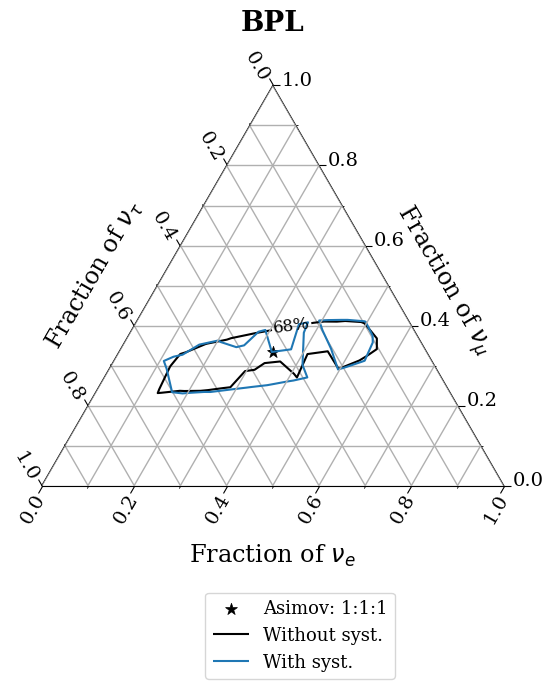

In [ ]:
# compare_syst_globalfit_double_no_hybrid_nohese_BPL
names = [
"globalfit_double_no_hybrid_nohese_BPL_nosyst",
"globalfit_double_no_hybrid_nohese_BPL"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"BPL",
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_nohese_BPL_nosyst", levels=["68%"] )



Combined
- SPL: seems fine. Did I include systematics?
    - Yes
- BPL: seems fine. Did I include?
    - Yes

Quite some: ABNORMAL_TERMINATION_IN_LNSRCH

Area ratio (globalfit_double_no_hybrid_hese_SPL_nosyst / globalfit_double_no_hybrid_hese_SPL_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_SPL / globalfit_double_no_hybrid_hese_SPL_nosyst) at 68%: 1.1746


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

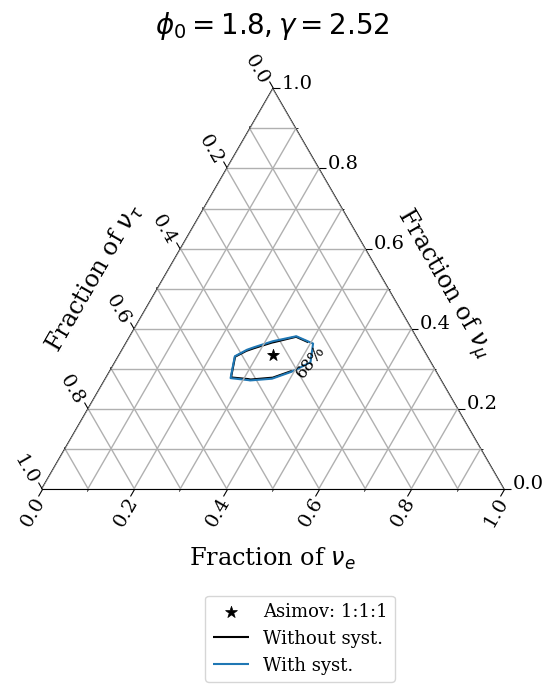

In [25]:
# compare_syst_globalfit_double_no_hybrid_hese_SPL
names = [
"globalfit_double_no_hybrid_hese_SPL_nosyst",
"globalfit_double_no_hybrid_hese_SPL"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 1.8,\gamma=2.52$",
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_hese_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_SPL_nosyst", levels=["68%"] )



Area ratio (globalfit_double_no_hybrid_hese_BPL_nosyst / globalfit_double_no_hybrid_hese_BPL_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_BPL / globalfit_double_no_hybrid_hese_BPL_nosyst) at 68%: 1.1239


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

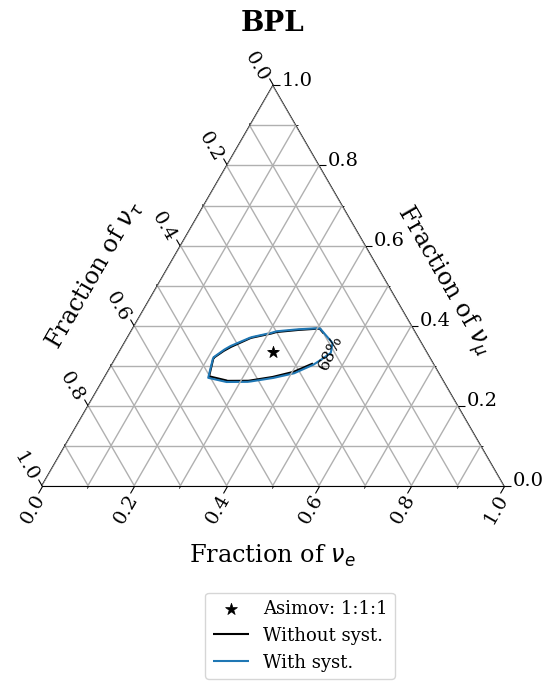

In [27]:
# compare_syst_globalfit_double_no_hybrid_hese_BPL
names = [
"globalfit_double_no_hybrid_hese_BPL_nosyst",
"globalfit_double_no_hybrid_hese_BPL"
]
labels = [
    "Without syst.",
    "With syst."
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"BPL",
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_hese_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_BPL_nosyst", levels=["68%"] )


Question from dough, study uncertainty

Area ratio (hese_HESEBestfit_SPL_noinel_nosyst_Poisson / hese_HESEBestfit_SPL_noinel_nosyst_Poisson) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_gamma_low / hese_HESEBestfit_SPL_noinel_nosyst_Poisson) at 68%: 0.7257
Area ratio (hese_HESEBestfit_SPL_gamma_high / hese_HESEBestfit_SPL_noinel_nosyst_Poisson) at 68%: 1.2559
Area ratio (hese_HESEBestfit_SPL_phi_low / hese_HESEBestfit_SPL_noinel_nosyst_Poisson) at 68%: 1.3663
Area ratio (hese_HESEBestfit_SPL_phi_high / hese_HESEBestfit_SPL_noinel_nosyst_Poisson) at 68%: 0.7671


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

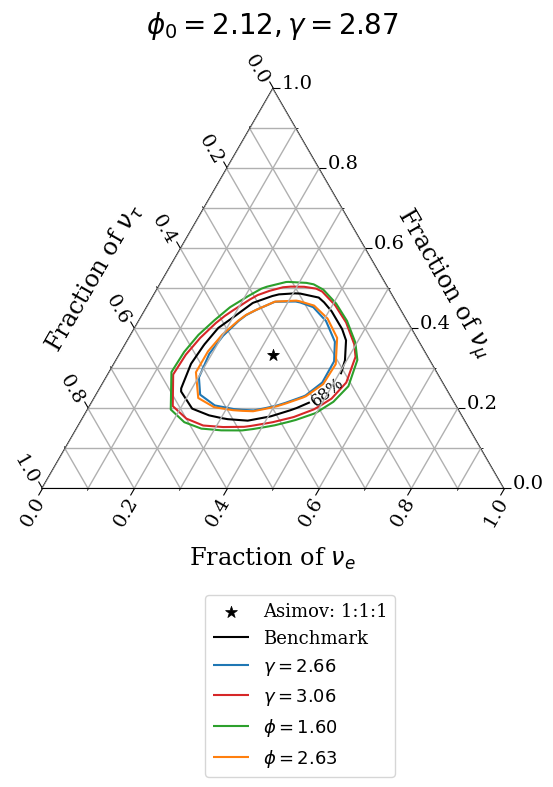

In [29]:
# compare_flux_uncertainty_doug_hese_HESEBestfit
names = [
"hese_HESEBestfit_SPL_noinel_nosyst_Poisson",
"hese_HESEBestfit_SPL_gamma_low",
"hese_HESEBestfit_SPL_gamma_high",
"hese_HESEBestfit_SPL_phi_low",
"hese_HESEBestfit_SPL_phi_high",
]
labels = [
    "Benchmark",
    r"$\gamma=2.66$",
    r"$\gamma=3.06$",
    r"$\phi=1.60$",
    r"$\phi=2.63$",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/compare_flux_uncertainty_doug_hese_HESEBestfit.png")

for name in names: compare_area( C, alt_key=name, base_key="hese_HESEBestfit_SPL_noinel_nosyst_Poisson", levels=["68%"] )


/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center / globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low_fine_center / globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center) at 68%: 1.1602
Area ratio (globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high_fine_center / globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center) at 68%: 0.7676
Area ratio (globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_high_fine_center / globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center) at 68%: 0.7103
Area ratio (globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_low_fine_center / globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center) at 68%: 1.6868


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

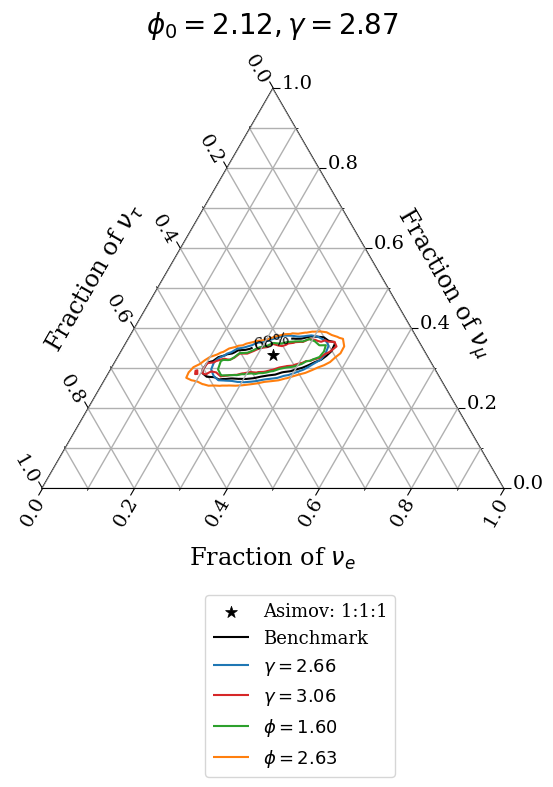

In [ ]:
# compare_flux_uncertainty_doug_globalfit_double_no_hybrid_hese_HESEBestfit
names = [
"globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center",
"globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_low_fine_center",
"globalfit_double_no_hybrid_hese_HESEBestfit_SPL_gamma_high_fine_center",
"globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_low_fine_center",
"globalfit_double_no_hybrid_hese_HESEBestfit_SPL_phi_high_fine_center",
]
labels = [
    "Benchmark",
    r"$\gamma=2.66$",
    r"$\gamma=3.06$",
    r"$\phi=1.60$",
    r"$\phi=2.63$",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/compare_flux_uncertainty_doug_globalfit_double_no_hybrid_hese_HESEBestfit.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_HESEBestfit_SPL_fine_center", levels=["68%"] )


Area ratio (globalfit_double_no_hybrid_hese_BPL_range_philipp / globalfit_double_no_hybrid_hese_BPL_range_philipp) at 68%: 1.0000


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:160: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()


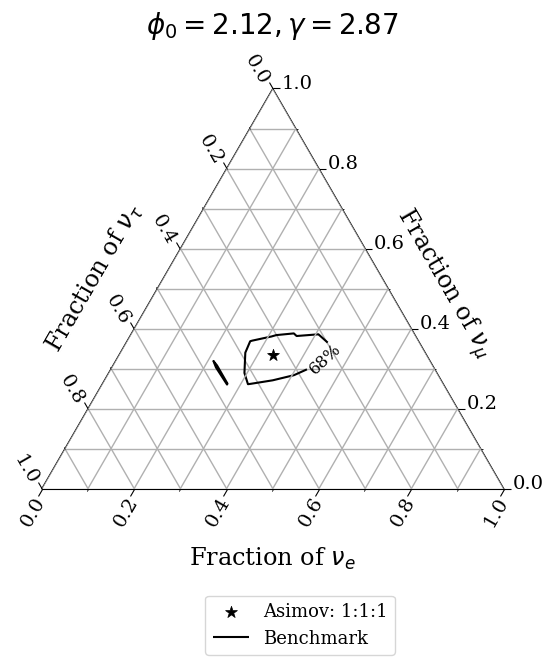

In [31]:
# compare_flux_uncertainty_doug_globalfit_double_no_hybrid_hese_BPL
names = [
"globalfit_double_no_hybrid_hese_BPL_range_philipp",
]
labels = [
    "Benchmark",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%"],
                  title = r"$\phi_0 = 2.12,\gamma=2.87$",
                  savepath = f"{plotting_path}/compare_flux_uncertainty_doug_globalfit_double_no_hybrid_hese_BPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_BPL_range_philipp", levels=["68%"] )
